# XQAA demo — retrieving IOPs from Rrs

A minimal, current example of the top-level XQAA workflow: feed a
remote-sensing reflectance spectrum (`Rrs`) to `xqaa.retrieve.iops_from_Rrs`
and recover the non-water absorption (`anw`) and particulate backscatter
(`bbp`).

Requires the `ocean14` environment (for `ocpy`).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ocpy.hydrolight import loisel23

from xqaa import params as xqaa_params
from xqaa import retrieve

## Load a Loisel+2023 spectrum

We use one spectrum from the X=4 variant as a stand-in for a real Rrs
observation, and keep the true IOPs for comparison.

In [2]:
# Default parameters (X=4 variant)
xparams = xqaa_params.XQAAParams()

# Load the reference dataset and pick one spectrum
l23_ds = loisel23.load_ds(xparams.L23_X, xparams.L23_Y)
idx = 170

wave = l23_ds.Lambda.data
Rrs = l23_ds.Rrs.data[idx]

# Truth (non-water backscatter) for comparison
bbnw_true = l23_ds.bbnw.data[idx]
print(f"wave: {wave.min():.0f}-{wave.max():.0f} nm, {wave.size} bands")

wave: 350-750 nm, 81 bands


## Run the retrieval

In [3]:
result = retrieve.iops_from_Rrs(wave, Rrs, xparams)
print(type(result).__name__)
print(f"anw[-1]  = {result.anw[-1]:.4e}")
print(f"bbp[-1]  = {result.bbp[-1]:.4e}")
print(f"avg_bbp  = {result.avg_bbp:.4e}")

XQAARetrieval
anw[-1]  = 1.5734e-02
bbp[-1]  = 3.8952e-04
avg_bbp  = 4.7157e-04


/home/xavier/Oceanography/python/xqaa/xqaa/retrieve.py:64: UserWarning: Need to implement b_w
  warnings.warn("Need to implement b_w")


## Compare retrieved bbp to the true non-water backscatter

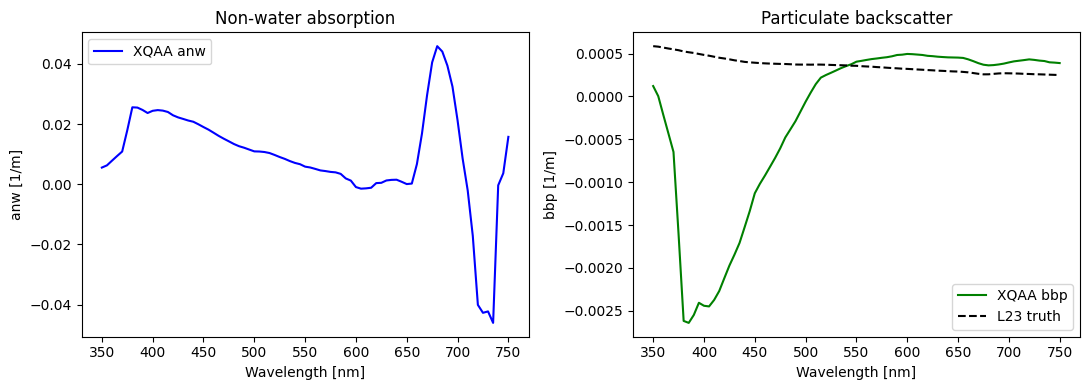

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(11, 4))

axs[0].plot(wave, result.anw, 'b-', label='XQAA anw')
axs[0].set_xlabel('Wavelength [nm]')
axs[0].set_ylabel('anw [1/m]')
axs[0].set_title('Non-water absorption')
axs[0].legend()

axs[1].plot(wave, result.bbp, 'g-', label='XQAA bbp')
axs[1].plot(wave, bbnw_true, 'k--', label='L23 truth')
axs[1].set_xlabel('Wavelength [nm]')
axs[1].set_ylabel('bbp [1/m]')
axs[1].set_title('Particulate backscatter')
axs[1].legend()

plt.tight_layout()
plt.show()